# MFPT Table Printer

This notebook prints `t = <T(n0)>` over a grid of `m0` and `r` values using the spectral Julia MFPT routine, with no comparisons or plots.

In [1]:
using Printf, Plots

candidates = [abspath(pwd()), abspath(joinpath(pwd(), "..")), abspath(joinpath(pwd(), "..", ".."))]
project_root = nothing
for p in candidates
    if isfile(joinpath(p, "src", "VoterResetting.jl"))
        global project_root = p
        break
    end
end
project_root === nothing && error("Could not locate project root containing src/VoterResetting.jl from pwd=$(pwd())")

include(joinpath(project_root, "src", "VoterResetting.jl"))
const VR = VoterResetting
println("Loaded VoterResetting from: $(project_root)")

Loaded VoterResetting from: c:\Users\gerar\Desktop\Escola\Universitat\Master\TFM\voter-model-stochastic-resetting\


In [5]:
N = 500
m0_values = collect(0.0:0.1:0.9)
r_values = collect(range(0.0, 0.95, length = 20))
precision_bits = 128

println("m0\tr\tt")
println(repeat("-", 64))
for m0 in m0_values
    for r in r_values
        n0 = clamp(round(Int, N * (1 + m0) / 2), 1, N - 1)
        t = VR.exact_mfpt_discrete_spectral(N, n0, r; precision_bits = precision_bits, return_bigfloat = false)
        @printf("%.1f\t%.6f\t%.16e\n", m0, r, t)
    end
end

m0	r	t
----------------------------------------------------------------
0.0	0.000000	1.7269097104920755e+05
0.0	0.050000	4.2914351111891894e+06
0.0	0.100000	4.5930459558348805e+07
0.0	0.150000	3.2846242970667595e+08
0.0	0.200000	1.8371160336552529e+09
0.0	0.250000	8.6676093554147625e+09
0.0	0.300000	3.6017273048170692e+10
0.0	0.350000	1.3547674006702827e+11
0.0	0.400000	4.6997920227245819e+11
0.0	0.450000	1.5240247171661423e+12
0.0	0.500000	4.6663662881190186e+12
0.0	0.550000	1.3596521056293887e+13
0.0	0.600000	3.7936197767134469e+13
0.0	0.650000	1.0189034544956514e+14
0.0	0.700000	2.6469042384407125e+14
0.0	0.750000	6.6846340455814988e+14
0.0	0.800000	1.6524963175675665e+15
0.0	0.850000	4.0470371993852375e+15
0.0	0.900000	1.0073934747754560e+16
0.0	0.950000	2.7257988400021860e+16
0.1	0.000000	1.7144138688128040e+05
0.1	0.050000	3.8046992081189919e+06
0.1	0.100000	3.6435747178890832e+07
0.1	0.150000	2.3478143469256142e+08
0.1	0.200000	1.1905340873285329e+09
0.1	0.250000	5.1197545697053

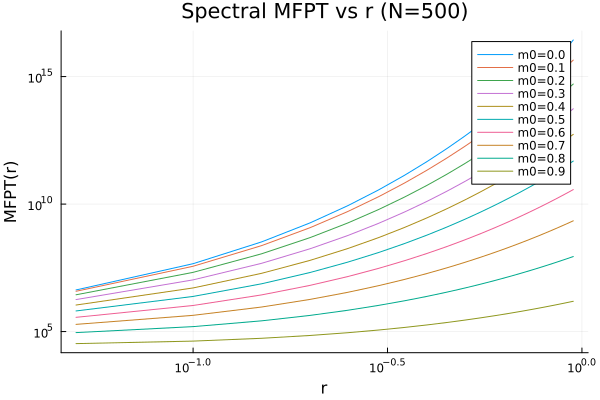

In [ ]:

gr()

p = plot(
    xlabel = "r",
    ylabel = "MFPT(r)",
    title = "Spectral MFPT vs r (N=$(N))",
    xscale = :log10,
    yscale = :log10,
    legend = :topright,
    linewidth = 2,
)

for m0 in m0_values
    n0 = clamp(round(Int, N * (1 + m0) / 2), 1, N - 1)
    t_values = [
        VR.exact_mfpt_discrete_spectral(
            N,
            n0,
            r;
            precision_bits = precision_bits,
            return_bigfloat = false,
        ) for r in r_values
    ]

    mask = isfinite.(t_values) .& (t_values .> 0.0) .& (r_values .> 0)
    rr = r_values[mask]
    tt = t_values[mask]
    isempty(tt) && continue

    plot!(p, rr, tt, label = @sprintf("m0=%.1f", m0))
end

p

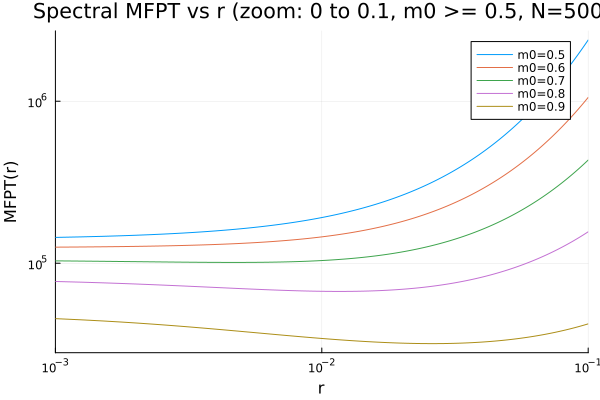

In [5]:
r_zoom = collect(range(0.0, 0.1, length = 400))
m0_zoom_values = filter(m0 -> m0 >= 0.5, m0_values)

p_zoom = plot(
    xlabel = "r",
    ylabel = "MFPT(r)",
    title = "Spectral MFPT vs r (zoom: 0 to 0.1, m0 >= 0.5, N=$(N))",
    xscale = :log10,
    yscale = :log10,
    legend = :topright,
    linewidth = 2,
    xlims = (0.001, 0.1),
)

for m0 in m0_zoom_values
    n0 = clamp(round(Int, N * (1 + m0) / 2), 1, N - 1)
    t_zoom = [
        VR.exact_mfpt_discrete_spectral(
            N,
            n0,
            r;
            precision_bits = precision_bits,
            return_bigfloat = false,
        ) for r in r_zoom
    ]

    mask = isfinite.(t_zoom) .& (t_zoom .> 0.0) .& (r_zoom .> 0)
    rr = r_zoom[mask]
    tt = t_zoom[mask]
    isempty(tt) && continue

    plot!(p_zoom, rr, tt, label = @sprintf("m0=%.1f", m0))
end

p_zoom

Theory scan: 100 m0 points, 180 coarse r points per m0


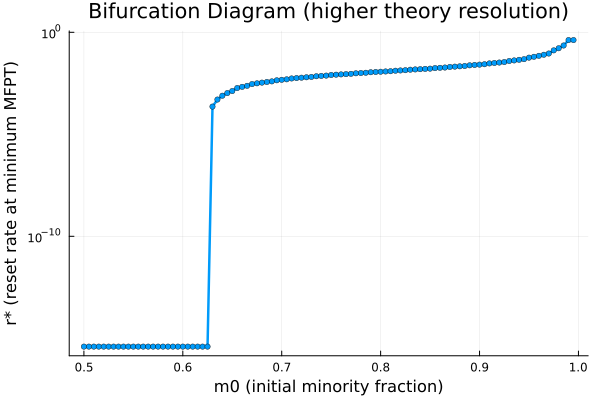

In [6]:
using Optim

# For each m0, find the r value that minimizes MFPT
# Increased theory resolution: denser m0 grid and more coarse r points
m0_fine = collect(0.50:0.005:0.995)
r_minima = Float64[]
mfpt_minima = Float64[]

r_coarse_max = min(0.40, 0.95)
r_coarse_points = 180
    r_fine_half_width = 0.015

for m0 in m0_fine
    n0 = clamp(round(Int, N * (1 + m0) / 2), 1, N - 1)
    
    # Objective function: MFPT as a function of r
    # Use adaptive search: first coarse, then fine
    function mfpt_func(r)
        if r < 0 || r >= 1
            return 1e10  # penalty
        end
        t = VR.exact_mfpt_discrete_spectral(N, n0, r; precision_bits=precision_bits, return_bigfloat=false)
        return isfinite(t) && t > 0 ? t : 1e10
    end
    
    # First: denser coarse search to find approximate minimum location
    r_coarse = collect(range(0.0, r_coarse_max, length = r_coarse_points))
    t_coarse = [mfpt_func(r) for r in r_coarse]
    
    valid_idx = findall(x -> isfinite(x) && x < 1e10, t_coarse)
    if isempty(valid_idx)
        continue  # skip if no valid points
    end
    
    # Find the r with minimum MFPT in coarse search
    min_coarse_idx = valid_idx[argmin(t_coarse[valid_idx])]
    r_approx = r_coarse[min_coarse_idx]
    
    # Second: fine search using Optim around the approximate minimum
    r_lower = max(0.0, r_approx - r_fine_half_width)
    r_upper = min(0.95, r_approx + r_fine_half_width)
    
    if r_upper > r_lower
        result = optimize(mfpt_func, r_lower, r_upper)
        r_min = Optim.minimizer(result)
        t_min = Optim.minimum(result)
    else
        r_min = r_approx
        t_min = mfpt_func(r_approx)
    end
    
    if isfinite(t_min) && t_min < 1e10
        push!(r_minima, r_min)
        push!(mfpt_minima, t_min)
    else
        push!(r_minima, NaN)
        push!(mfpt_minima, NaN)
    end
end

println(@sprintf("Theory scan: %d m0 points, %d coarse r points per m0", length(m0_fine), r_coarse_points))

# Filter for valid points (nonzero and finite) for bifurcation plot
valid_mask = (m0_fine .> 0) .& isfinite.(r_minima) .& (r_minima .> 0)
m0_plot = m0_fine[valid_mask]
r_plot = r_minima[valid_mask]

# Create bifurcation diagram
p_bifurc = plot(
    m0_plot,
    r_plot,
    xlabel="m0 (initial minority fraction)",
    ylabel="r* (reset rate at minimum MFPT)",
    title="Bifurcation Diagram (higher theory resolution)",
    legend=false,
    linewidth=2.5,
    markerstrokewidth=0.5,
    markersize=3,
    marker=:circle,
    yscale=:log10,
)

p_bifurc

In [7]:
# Summary table of bifurcation points
println("\n" * repeat("=", 70))
println("BIFURCATION DIAGRAM: Minimum Location Summary")
println(repeat("=", 70))
println(@sprintf("%8s | %12s | %12s", "m0", "r* (min loc)", "MFPT(r*)"))
println(repeat("-", 70))

for (m0, r_min, t_min) in zip(m0_fine, r_minima, mfpt_minima)
    if isfinite(r_min) && isfinite(t_min)
        println(@sprintf("%8.3f | %12.6e | %12.6e", m0, r_min, t_min))
    else
        println(@sprintf("%8.3f | %12s | %12s", m0, "N/A", "N/A"))
    end
end
println(repeat("=", 70))

# Identify bifurcation point
bifurc_idx = findfirst(r -> isfinite(r) && r > 1e-6, r_minima)
if bifurc_idx !== nothing
    bifurc_m0 = m0_fine[bifurc_idx]
    println("\n✓ Bifurcation onset detected at m0 ≈ $(bifurc_m0)")
else
    println("\n✓ No clear bifurcation detected in m0 range")
end


BIFURCATION DIAGRAM: Minimum Location Summary
      m0 | r* (min loc) |     MFPT(r*)
----------------------------------------------------------------------
   0.500 | 3.907461e-16 | 1.400535e+05
   0.505 | 3.907461e-16 | 1.395026e+05
   0.510 | 3.907461e-16 | 1.383848e+05
   0.515 | 3.907461e-16 | 1.378178e+05
   0.520 | 3.907461e-16 | 1.372453e+05
   0.525 | 3.907461e-16 | 1.366674e+05
   0.530 | 3.907461e-16 | 1.360840e+05
   0.535 | 3.907461e-16 | 1.349005e+05
   0.540 | 3.907461e-16 | 1.343003e+05
   0.545 | 3.907461e-16 | 1.336946e+05
   0.550 | 3.907461e-16 | 1.324660e+05
   0.555 | 3.907461e-16 | 1.318431e+05
   0.560 | 3.907461e-16 | 1.312144e+05
   0.565 | 3.907461e-16 | 1.305800e+05
   0.570 | 3.907461e-16 | 1.299396e+05
   0.575 | 3.907461e-16 | 1.286412e+05
   0.580 | 3.907461e-16 | 1.279831e+05
   0.585 | 3.907461e-16 | 1.273190e+05
   0.590 | 3.907461e-16 | 1.266488e+05
   0.595 | 3.907461e-16 | 1.252900e+05
   0.600 | 3.907461e-16 | 1.246013e+05
   0.605 | 3.907461e-16 

In [ ]:
using Printf
using Statistics
using Random
using Plots

Random.seed!(1234)

m0_sim_values = collect(0.50:0.02:0.98)
r_coarse_sim = collect(range(0.0, 0.25, length = 11))
r_fine_half_width = 0.015
nsamples_coarse = 7000
nsamples_fine = 10000

function mean_fpt_all_to_all_sim(N::Int, m0::Real, r::Real; nsamples::Int = 250, consensus_type::Symbol = :either)
    reset = VR.delta_reset(m0)
    total = 0.0
    @inbounds for _ in 1:nsamples
        total += VR.simulate_fpt_all_to_all_trajectory(
            N,
            Float64(m0),
            Float64(r),
            reset,
            consensus_type,
        )
    end
    return total / nsamples
end

function best_r_from_simulation(N::Int, m0::Real;
                                r_coarse = r_coarse_sim,
                                nsamples_coarse::Int = nsamples_coarse,
                                nsamples_fine::Int = nsamples_fine,
                                consensus_type::Symbol = :either)
    coarse_means = [mean_fpt_all_to_all_sim(N, m0, r; nsamples = nsamples_coarse, consensus_type = consensus_type) for r in r_coarse]
    best_coarse_idx = argmin(coarse_means)
    r_approx = r_coarse[best_coarse_idx]

    r_left = max(first(r_coarse), r_approx - r_fine_half_width)
    r_right = min(last(r_coarse), r_approx + r_fine_half_width)
    r_fine = collect(range(r_left, r_right, length = 9))
    fine_means = [mean_fpt_all_to_all_sim(N, m0, r; nsamples = nsamples_fine, consensus_type = consensus_type) for r in r_fine]
    best_fine_idx = argmin(fine_means)

    return r_fine[best_fine_idx], fine_means[best_fine_idx], r_approx, coarse_means[best_coarse_idx]
end

println(@sprintf("Running simulation scan for %d m0 values", length(m0_sim_values)))
t_sim_scan = time()

r_minima_sim = Float64[]
mfpt_minima_sim = Float64[]
r_approx_sim = Float64[]
mfpt_approx_sim = Float64[]

for m0 in m0_sim_values
    r_min, t_min, r_guess, t_guess = best_r_from_simulation(N, m0)
    push!(r_minima_sim, r_min)
    push!(mfpt_minima_sim, t_min)
    push!(r_approx_sim, r_guess)
    push!(mfpt_approx_sim, t_guess)
end

valid_mask_sim = isfinite.(r_minima_sim) .& (r_minima_sim .>= 0.0)
println(@sprintf("Simulation scan elapsed: %.2f s", time() - t_sim_scan))

# Match each simulation m0 to the nearest theory m0 point (robust for dense/nonuniform grids).
theory_r_on_sim = [begin
    idx = argmin(abs.(m0_fine .- m0))
    r_minima[idx]
end for m0 in m0_sim_values]

compare_mask = valid_mask_sim .& isfinite.(theory_r_on_sim) .& (theory_r_on_sim .>= 0.0)
m0_compare = m0_sim_values[compare_mask]
r_sim_compare = r_minima_sim[compare_mask]
r_theory_compare = theory_r_on_sim[compare_mask]
delta_r_compare = r_sim_compare .- r_theory_compare

p_compare_curve = plot(
    xlabel = "m0",
    ylabel = "r*",
    title = "Simulation vs Theory Bifurcation (N=$(N))",
    legend = :topright,
    linewidth = 2.5,
    marker = :circle,
    markersize = 4,
    markerstrokewidth = 0.5,
    xlims = (0.5, 1.0),
)

plot!(p_compare_curve, m0_compare, r_theory_compare, label = "theory", color = :black, linestyle = :dash)
plot!(p_compare_curve, m0_compare, r_sim_compare, label = "simulation", color = :red)

p_compare_delta = plot(
    m0_compare,
    delta_r_compare,
    xlabel = "m0",
    ylabel = "Δr* = r*_sim - r*_theory",
    title = "Simulation-theory difference",
    legend = false,
    linewidth = 2.0,
    marker = :circle,
    markersize = 4,
    xlims = (0.5, 1.0),
)

hline!(p_compare_delta, [0.0], color = :gray, linestyle = :dash)

p_compare = plot(p_compare_curve, p_compare_delta, layout = (2, 1), size = (900, 800))

println(@sprintf("mean |Δr*| = %.6e", mean(abs.(delta_r_compare))))
println(@sprintf("max  |Δr*| = %.6e", maximum(abs.(delta_r_compare))))

p_compare

Running simulation scan for 25 m0 values

In [ ]:
# All-to-all MFPT comparison for selected m0 and r values.
# In discrete time, r is a probability (not a rate), so theory and simulation are already in the same time units (steps).
comparison_m0_values = [0.2, 0.5, 0.7, 0.9]
comparison_r_values = [0.01, 0.03, 0.05, 0.10, 0.20, 0.35]
nsamples_compare = 2000

using Random, Statistics, Plots
gr()

function threaded_mean_fpt_all_to_all(N::Int, m0::Real, r::Real; nsamples::Int = 1000)
    nthreads = Threads.nthreads()
    counts = fill(div(nsamples, nthreads), nthreads)
    for i in 1:mod(nsamples, nthreads)
        counts[i] += 1
    end

    partial_sums = zeros(Float64, nthreads)
    Threads.@threads for tid in 1:nthreads
        nlocal = counts[tid]
        if nlocal == 0
            continue
        end
        res = VR.first_passage_time_all_to_all(
            VR.AllToAllParams(N, r, m0);
            nsamples = nlocal,
            consensus_type = :either,
        )
        partial_sums[tid] = res.mean_fpt * nlocal
    end

    return sum(partial_sums) / nsamples
end

println("\n" * repeat("=", 88))
println("ALL-TO-ALL MFPT COMPARISON: theory vs simulation (discrete time, r is probability)")
println(repeat("=", 88))
println(@sprintf("%-6s %-8s %-20s %-20s %-12s", "m0", "r", "MFPT_theory", "MFPT_sim", "rel_err"))
println(repeat("-", 88))

all_to_all_theory_pts = []
all_to_all_sim_pts = []

for m0 in comparison_m0_values
    n0 = clamp(round(Int, N * (1 + m0) / 2), 1, N - 1)

    for r in comparison_r_values
        t_th = VR.exact_mfpt_discrete_spectral(
            N,
            n0,
            r;
            precision_bits = precision_bits,
            return_bigfloat = false,
        )
        t_sim = threaded_mean_fpt_all_to_all(N, m0, r; nsamples = nsamples_compare)

        push!(all_to_all_theory_pts, (m0 = m0, r = r, mfpt = t_th))
        push!(all_to_all_sim_pts, (m0 = m0, r = r, mfpt = t_sim))

        rel_err = isfinite(t_th) && t_th > 0 ? abs(t_sim - t_th) / t_th : NaN
        println(@sprintf("%-6.2f %-8.3f %-20.8e %-20.8e %-12.6e", m0, r, t_th, t_sim, rel_err))
    end
end

println(repeat("=", 88))

# Scatter plot: MFPT vs r, with different colors for each m0
p_all_to_all = plot(
    xlabel = "r",
    ylabel = "MFPT",
    title = "All-to-All: MFPT vs r (theory vs simulation)",
    xscale = :log10,
    yscale = :log10,
    legend = :topright,
    size = (900, 600),
)

m0_colors = Dict(0.2 => :blue, 0.5 => :green, 0.7 => :orange, 0.9 => :red)

for pt in all_to_all_theory_pts
    scatter!(p_all_to_all, [pt.r], [pt.mfpt],
        color = m0_colors[pt.m0],
        marker = :x,
        markersize = 8,
        label = "")
end

for pt in all_to_all_sim_pts
    scatter!(p_all_to_all, [pt.r], [pt.mfpt],
        color = m0_colors[pt.m0],
        marker = :circle,
        markersize = 5,
        label = "")
end

p_all_to_all




ALL-TO-ALL MFPT COMPARISON: theory vs simulation (discrete time, r is probability)
m0     r        MFPT_theory          MFPT_sim             rel_err     
----------------------------------------------------------------------------------------
0.20   0.010    3.28935368e+05       6.65748451e+02       9.979761e-01
0.20   0.030    1.04026657e+06       2.11239862e+03       9.979694e-01
0.20   0.050    2.77200733e+06       5.50322799e+03       9.980147e-01
0.20   0.100    2.10091085e+07       4.13162396e+04       9.980334e-01



COMPLEX-NETWORK MFPT COMPARISON: theory vs simulation (threaded discrete-time)
network    m0     r        MFPT_theory          MFPT_sim             rel_err     
----------------------------------------------------------------------------------------
Built ER μ=4   with N=500, mean degree≈3.90, edges=975
FAILED to build ER μ=4: UndefVarError(:comparison_m0_values, 0x0000000000009fb6, Main)
Built ER μ=90  with N=500, mean degree≈88.87, edges=22217
FAILED to build ER μ=90: UndefVarError(:comparison_m0_values, 0x0000000000009fb6, Main)
Built BA μ=10  with N=500, mean degree≈9.90, edges=2475
FAILED to build BA μ=10: UndefVarError(:comparison_m0_values, 0x0000000000009fb6, Main)
Built BA μ=50  with N=500, mean degree≈47.50, edges=11875
FAILED to build BA μ=50: UndefVarError(:comparison_m0_values, 0x0000000000009fb6, Main)


┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194


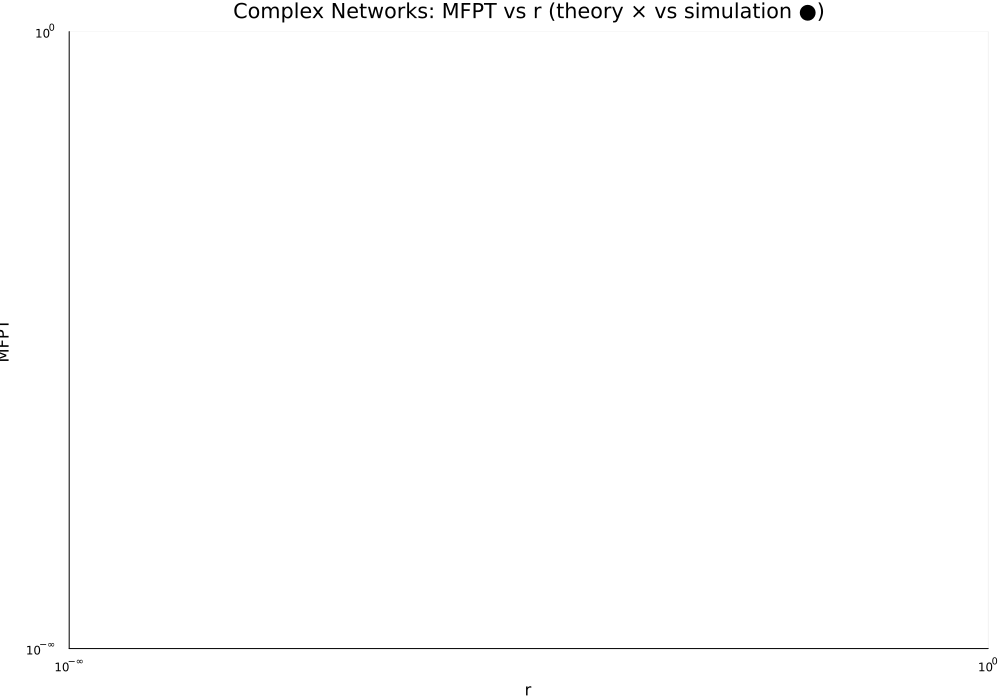

┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194
┌ Warning: No strict ticks found
└ @ PlotUtils C:\Users\gerar\.julia\packages\PlotUtils\HX80C\src\ticks.jl:194


In [8]:
# Complex-network MFPT comparison using the same parameter grid.
# Theory uses complex_mfpt; simulation uses threaded discrete-time first_passage_time_discrete_complex.
using Graphs

comparison_networks = [
    ("ER μ=4", 4.0, (N, mu) -> erdos_renyi(N, mu / (N - 1))),
    ("ER μ=90", 90.0, (N, mu) -> erdos_renyi(N, mu / (N - 1))),
    ("BA μ=10", 10.0, (N, mu) -> barabasi_albert(N, max(1, round(Int, mu / 2)))),
    ("BA μ=50", 50.0, (N, mu) -> barabasi_albert(N, max(1, round(Int, mu / 2)))),
]

nsamples_compare_complex = 500

function threaded_mean_fpt_complex(graph, m0::Real, r::Real; nsamples::Int = 500)
    nthreads = Threads.nthreads()
    counts = fill(div(nsamples, nthreads), nthreads)
    for i in 1:mod(nsamples, nthreads)
        counts[i] += 1
    end

    partial_sums = zeros(Float64, nthreads)
    partial_counts = zeros(Int, nthreads)
    Threads.@threads for tid in 1:nthreads
        nlocal = counts[tid]
        if nlocal == 0
            continue
        end
        samples = VR.first_passage_time_discrete_complex(
            graph,
            VR.ComplexParams(r, m0);
            nsamples = nlocal,
            wait_for_consensus = true,
            reset = VR.delta_reset(m0),
        )
        partial_sums[tid] = sum(samples)
        partial_counts[tid] = length(samples)
    end

    total_count = sum(partial_counts)
    if total_count == 0
        return NaN
    end
    total_sum = sum(partial_sums)
    return total_sum / total_count
end

println("\n" * repeat("=", 88))
println("COMPLEX-NETWORK MFPT COMPARISON: theory vs simulation (threaded discrete-time)")
println(repeat("=", 88))
println(@sprintf("%-10s %-6s %-8s %-20s %-20s %-12s", "network", "m0", "r", "MFPT_theory", "MFPT_sim", "rel_err"))
println(repeat("-", 88))

complex_theory_pts = []
complex_sim_pts = []

for (label, mu_target, ctor) in comparison_networks
    try
        g = ctor(N, mu_target)
        actual_mean_k = 2 * ne(g) / nv(g)
        println(@sprintf("Built %-8s with N=%d, mean degree≈%.2f, edges=%d", label, nv(g), actual_mean_k, ne(g)))

        for m0 in comparison_m0_values
            for r in comparison_r_values
                try
                    t_th = VR.complex_mfpt(g, m0; r = r)
                    t_sim = threaded_mean_fpt_complex(g, m0, r; nsamples = nsamples_compare_complex)

                    push!(complex_theory_pts, (network = label, m0 = m0, r = r, mfpt = t_th))
                    push!(complex_sim_pts, (network = label, m0 = m0, r = r, mfpt = t_sim))

                    rel_err = isfinite(t_th) && t_th > 0 ? abs(t_sim - t_th) / t_th : NaN
                    println(@sprintf("%-10s %-6.2f %-8.3f %-20.8e %-20.8e %-12.6e", label, m0, r, t_th, t_sim, rel_err))
                catch e
                    println(@sprintf("%-10s %-6.2f %-8.3f ERROR: %s", label, m0, r, string(e)))
                end
            end
        end
    catch e
        println(@sprintf("FAILED to build %s: %s", label, string(e)))
    end
end

println(repeat("=", 88))

p_complex = plot(
    xlabel = "r",
    ylabel = "MFPT",
    title = "Complex Networks: MFPT vs r (theory × vs simulation ●)",
    xscale = :log10,
    yscale = :log10,
    legend = :topright,
    size = (1000, 700),
)

network_colors = Dict("ER μ=4" => :blue, "ER μ=90" => :green, "BA μ=10" => :orange, "BA μ=50" => :red)
m0_alphas = Dict(0.2 => 0.4, 0.5 => 0.6, 0.7 => 0.8, 0.9 => 1.0)

for pt in complex_theory_pts
    scatter!(p_complex, [pt.r], [pt.mfpt],
        color = network_colors[pt.network],
        marker = :x,
        markersize = 8,
        alpha = m0_alphas[pt.m0],
        label = "")
end

for pt in complex_sim_pts
    scatter!(p_complex, [pt.r], [pt.mfpt],
        color = network_colors[pt.network],
        marker = :circle,
        markersize = 5,
        alpha = m0_alphas[pt.m0],
        label = "")
end

p_complex

In [ ]:
# Complex-network MFPT comparison using the same parameter grid.
# Theory uses complex_mfpt; simulation uses threaded discrete-time first_passage_time_discrete_complex.
using Graphs

# Ensure key variables are defined (cells may be run out-of-order)
if !@isdefined comparison_m0_values
    comparison_m0_values = [0.2, 0.5, 0.7, 0.9]
end
if !@isdefined comparison_r_values
    comparison_r_values = [0.01, 0.03, 0.05, 0.10, 0.20, 0.35]
end
if !@isdefined N
    N = 500
end

comparison_networks = [
    ("ER μ=4", 4.0, (N, mu) -> erdos_renyi(N, mu / (N - 1))),
    ("ER μ=90", 90.0, (N, mu) -> erdos_renyi(N, mu / (N - 1))),
    ("BA μ=10", 10.0, (N, mu) -> barabasi_albert(N, max(1, round(Int, mu / 2)))),
    ("BA μ=50", 50.0, (N, mu) -> barabasi_albert(N, max(1, round(Int, mu / 2)))),
]

nsamples_compare_complex = 500

function threaded_mean_fpt_complex(graph, m0::Real, r::Real; nsamples::Int = 500)
    nthreads = Threads.nthreads()
    counts = fill(div(nsamples, nthreads), nthreads)
    for i in 1:mod(nsamples, nthreads)
        counts[i] += 1
    end

    partial_sums = zeros(Float64, nthreads)
    partial_counts = zeros(Int, nthreads)
    Threads.@threads for tid in 1:nthreads
        nlocal = counts[tid]
        if nlocal == 0
            continue
        end
        samples = VR.first_passage_time_discrete_complex(
            graph,
            VR.ComplexParams(r, m0);
            nsamples = nlocal,
            wait_for_consensus = true,
            reset = VR.delta_reset(m0),
        )
        # Only include finite, positive samples when aggregating
        valid_mask = map(x -> isfinite(x) && x > 0, samples)
        partial_sums[tid] = sum(samples[valid_mask])
        partial_counts[tid] = count(valid_mask)
    end

    total_count = sum(partial_counts)
    if total_count == 0
        return NaN
    end
    total_sum = sum(partial_sums)
    return total_sum / total_count
end

println("\n" * repeat("=", 88))
println("COMPLEX-NETWORK MFPT COMPARISON: theory vs simulation (threaded discrete-time)")
println(repeat("=", 88))
println(@sprintf("%-10s %-6s %-8s %-20s %-20s %-12s", "network", "m0", "r", "MFPT_theory", "MFPT_sim", "rel_err"))
println(repeat("-", 88))

complex_theory_pts = []
complex_sim_pts = []

for (label, mu_target, ctor) in comparison_networks
    try
        g = ctor(N, mu_target)
        actual_mean_k = 2 * ne(g) / nv(g)
        println(@sprintf("Built %-8s with N=%d, mean degree≈%.2f, edges=%d", label, nv(g), actual_mean_k, ne(g)))

        for m0 in comparison_m0_values
            for r in comparison_r_values
                try
                    # Compute theory first. If theory MFPT is huge, skip simulation to avoid very long runs.
                    t_th = VR.complex_mfpt(g, m0; r = r)
                    max_allowed_theory = 1e6   # skip simulations if theory predicts > 1e6 steps
                    if !isfinite(t_th) || t_th > max_allowed_theory
                        # record and skip expensive simulation
                        push!(complex_theory_pts, (network = label, m0 = m0, r = r, mfpt = t_th))
                        push!(complex_sim_pts, (network = label, m0 = m0, r = r, mfpt = NaN))
                        println(@sprintf("%-10s %-6.2f %-8.3f %-20.8e %-20s %-12s", label, m0, r, t_th, "SKIPPED", "NaN"))
                        continue
                    end

                    # otherwise run a modest number of samples
                    t_sim = threaded_mean_fpt_complex(g, m0, r; nsamples = min(nsamples_compare_complex, 300))

                    push!(complex_theory_pts, (network = label, m0 = m0, r = r, mfpt = t_th))
                    push!(complex_sim_pts, (network = label, m0 = m0, r = r, mfpt = t_sim))

                    rel_err = isfinite(t_th) && t_th > 0 ? abs(t_sim - t_th) / t_th : NaN
                    println(@sprintf("%-10s %-6.2f %-8.3f %-20.8e %-20.8e %-12.6e", label, m0, r, t_th, t_sim, rel_err))
                catch e
                    println(@sprintf("%-10s %-6.2f %-8.3f ERROR: %s", label, m0, r, string(e)))
                end
            end
        end
    catch e
        println(@sprintf("FAILED to build %s: %s", label, string(e)))
    end
end

println(repeat("=", 88))

p_complex = plot(
    xlabel = "r",
    ylabel = "MFPT",
    title = "Complex Networks: MFPT vs r (theory × vs simulation ●)",
    xscale = :log10,
    yscale = :log10,
    legend = :topright,
    size = (1000, 700),
)

network_colors = Dict("ER μ=4" => :blue, "ER μ=90" => :green, "BA μ=10" => :orange, "BA μ=50" => :red)
m0_alphas = Dict(0.2 => 0.4, 0.5 => 0.6, 0.7 => 0.8, 0.9 => 1.0)

for pt in complex_theory_pts
    scatter!(p_complex, [pt.r], [pt.mfpt],
        color = network_colors[pt.network],
        marker = :x,
        markersize = 8,
        alpha = m0_alphas[pt.m0],
        label = "")
end

for pt in complex_sim_pts
    scatter!(p_complex, [pt.r], [pt.mfpt],
        color = network_colors[pt.network],
        marker = :circle,
        markersize = 5,
        alpha = m0_alphas[pt.m0],
        label = "")
end

p_complex


COMPLEX-NETWORK MFPT COMPARISON: theory vs simulation (threaded discrete-time)
network    m0     r        MFPT_theory          MFPT_sim             rel_err     
----------------------------------------------------------------------------------------
Built ER μ=4   with N=500, mean degree≈4.20, edges=1049


In [4]:
using Random, Graphs, Statistics, Printf

# Targeted diagnostic: test delta_reset vs random_node_reset with moderate N

println("\n" * repeat("=", 110))
println("TARGETED DIAGNOSTIC: delta_reset vs random_node_reset (N=150, inspect raw samples)")
println(repeat("=", 110))

N_target_diag = 150
mu_diag_targeted = 4.0
m0_diag_targeted = 0.8
r_diag_test = [0.01, 0.05, 0.1, 0.2]
nsamples_per_test = 100

Random.seed!(9999)
g_full_targeted = erdos_renyi(N_target_diag, mu_diag_targeted / (N_target_diag - 1))
components_targeted = connected_components(g_full_targeted)
largest_idx_targeted = argmax(length.(components_targeted))
largest_nodes_targeted = components_targeted[largest_idx_targeted]
g_targeted, _ = induced_subgraph(g_full_targeted, largest_nodes_targeted)

actual_mu_targeted = 2 * ne(g_targeted) / nv(g_targeted)
println(@sprintf("Built ER graph: N=%d, mean degree=%.2f, edges=%d\n", nv(g_targeted), actual_mu_targeted, ne(g_targeted)))

function test_reset_type(graph, reset_obj, reset_name::String, m0::Real, r::Real; nsamples::Int = 100)
    samples = VR.first_passage_time_discrete_complex(
        graph,
        VR.ComplexParams(r, m0);
        nsamples = nsamples,
        wait_for_consensus = true,
        reset = reset_obj,
    )
    
    n_zeros = count(==(0), samples)
    n_nans = count(isnan, samples)
    n_valid = count(x -> isfinite(x) && x > 0, samples)
    
    mean_val = n_valid > 0 ? mean(filter(x -> isfinite(x) && x > 0, samples)) : NaN
    min_val = n_valid > 0 ? minimum(filter(x -> isfinite(x) && x > 0, samples)) : NaN
    max_val = n_valid > 0 ? maximum(filter(x -> isfinite(x) && x > 0, samples)) : NaN
    
    first_5 = samples[1:min(5, length(samples))]
    
    return (
        reset_name = reset_name,
        n_zeros = n_zeros,
        n_nans = n_nans,
        n_valid = n_valid,
        mean_val = mean_val,
        min_val = min_val,
        max_val = max_val,
        first_5 = first_5,
    )
end

println(@sprintf("%-8s %-20s %-10s %-10s %-10s %-15s %-15s %-15s", 
                 "r", "reset_type", "n_valid", "n_zeros", "n_nans", "min", "mean", "max"))
println(repeat("-", 110))

for r in r_diag_test
    reset_delta = VR.delta_reset(m0_diag_targeted)
    reset_random = VR.random_node_reset(m0_diag_targeted)
    
    result_delta = test_reset_type(g_targeted, reset_delta, "delta_reset", m0_diag_targeted, r; nsamples = nsamples_per_test)
    result_random = test_reset_type(g_targeted, reset_random, "random_node", m0_diag_targeted, r; nsamples = nsamples_per_test)
    
    println(@sprintf("%-8.3f %-20s %-10d %-10d %-10d %-15.2f %-15.2f %-15.2f", 
                     r, result_delta.reset_name, result_delta.n_valid, result_delta.n_zeros, result_delta.n_nans,
                     result_delta.min_val, result_delta.mean_val, result_delta.max_val))
    
    sampstr_delta = string(round.(result_delta.first_5, digits=1))
    sampstr_random = string(round.(result_random.first_5, digits=1))
    
    println(@sprintf("%-8s %-20s %-10d %-10d %-10d %-15.2f %-15.2f %-15.2f  %s", 
                     "", result_random.reset_name, result_random.n_valid, result_random.n_zeros, result_random.n_nans,
                     result_random.min_val, result_random.mean_val, result_random.max_val, sampstr_random))
    println()
end

println(repeat("=", 110))



TARGETED DIAGNOSTIC: delta_reset vs random_node_reset (N=150, inspect raw samples)
Built ER graph: N=146, mean degree=4.21, edges=307

r        reset_type           n_valid    n_zeros    n_nans     min             mean            max            
--------------------------------------------------------------------------------------------------------------
0.010    delta_reset          100        0          0          34.00           668.80          3698.00        
         random_node          100        0          0          13.00           757.74          3502.00          [40.0, 556.0, 1135.0, 13.0, 1281.0]

0.050    delta_reset          100        0          0          28.00           2730.56         14160.00       
         random_node          100        0          0          28.00           1148.38         6118.00          [1337.0, 1796.0, 1390.0, 1881.0, 1631.0]

0.100    delta_reset          100        0          0          153.00          10737.79        67938.00       
      

In [5]:
using Random, Graphs, Statistics, Printf

# Test with INCREASING N to find threshold where zeros appear

println("\n" * repeat("=", 110))
println("N-SCALING TEST: Find threshold where zeros appear (delta_reset, r=0.05, m0=0.8)")
println(repeat("=", 110))

m0_test = 0.8
r_test = 0.05
nsamples_test = 50
mu_test = 4.0

N_values_test = [50, 100, 150, 200, 250, 300, 400, 500]

println(@sprintf("%-8s %-10s %-10s %-10s %-15s %-15s %-15s %-15s", 
                 "N", "n_valid", "n_zeros", "n_nans", "min", "mean", "max", "status"))
println(repeat("-", 110))

for N_test in N_values_test
    # Build graph
    Random.seed!(2027 + N_test)  # Different seed for each N
    g_test = erdos_renyi(N_test, mu_test / (N_test - 1))
    
    # Get giant component
    components_test = connected_components(g_test)
    if length(components_test) > 1
        largest_idx_test = argmax(length.(components_test))
        largest_nodes_test = components_test[largest_idx_test]
        g_test, _ = induced_subgraph(g_test, largest_nodes_test)
    end
    
    N_actual = nv(g_test)
    
    # Run samples with delta_reset
    reset_test = VR.delta_reset(m0_test)
    samples_test = VR.first_passage_time_discrete_complex(
        g_test,
        VR.ComplexParams(r_test, m0_test);
        nsamples = nsamples_test,
        wait_for_consensus = true,
        reset = reset_test,
    )
    
    n_zeros_test = count(==(0), samples_test)
    n_nans_test = count(isnan, samples_test)
    n_valid_test = count(x -> isfinite(x) && x > 0, samples_test)
    
    mean_test = n_valid_test > 0 ? mean(filter(x -> isfinite(x) && x > 0, samples_test)) : NaN
    min_test = n_valid_test > 0 ? minimum(filter(x -> isfinite(x) && x > 0, samples_test)) : NaN
    max_test = n_valid_test > 0 ? maximum(filter(x -> isfinite(x) && x > 0, samples_test)) : NaN
    
    status = n_zeros_test > 0 ? "⚠️  ZEROS" : "✓ valid"
    
    println(@sprintf("%-8d %-10d %-10d %-10d %-15.1f %-15.1f %-15.1f   %s", 
                     N_actual, n_valid_test, n_zeros_test, n_nans_test, 
                     min_test, mean_test, max_test, status))
end

println(repeat("=", 110))



N-SCALING TEST: Find threshold where zeros appear (delta_reset, r=0.05, m0=0.8)
N        n_valid    n_zeros    n_nans     min             mean            max             status         
--------------------------------------------------------------------------------------------------------------
50       50         0          0          3.0             76.4            465.0             ✓ valid
100      50         0          0          15.0            421.3           2072.0            ✓ valid
147      50         0          0          31.0            2509.5          9142.0            ✓ valid
198      50         0          0          436.0           11283.1         39394.0           ✓ valid
247      50         0          0          1368.0          56858.8         204180.0          ✓ valid
296      50         0          0          3057.0          262456.8        846766.0          ✓ valid
390      50         0          0          63961.0         5100407.4       23770903.0        ✓ valid
49


QUICK THEORY vs SIMULATION CHECK (complex network, delta dist + random-node protocol)
Graph: N=150, mean degree=4.29, edges=322

r        theory         simulation     rel_err       
----------------------------------------------------------------------
distribution = DeltaReset
protocol     = RandomNodeReset

0.005    2.368298e+00   1.790667e+01   6.560986e+00  
0.038    1.909394e+00   6.580000e+00   2.446120e+00  
0.071    1.915359e+00   5.580000e+00   1.913291e+00  
0.104    1.960774e+00   3.580000e+00   8.258097e-01  
0.137    2.021727e+00   3.333333e+00   6.487555e-01  
0.170    2.092937e+00   3.860000e+00   8.442980e-01  
0.203    2.172980e+00   3.726667e+00   7.150028e-01  
0.235    2.261728e+00   2.700000e+00   1.937774e-01  
0.268    2.359671e+00   2.700000e+00   1.442272e-01  
0.301    2.467700e+00   2.646667e+00   7.252380e-02  
0.334    2.587047e+00   2.706667e+00   4.623777e-02  
0.367    2.719302e+00   2.466667e+00   9.290447e-02  
0.400    2.866461e+00   2.733333e+00   

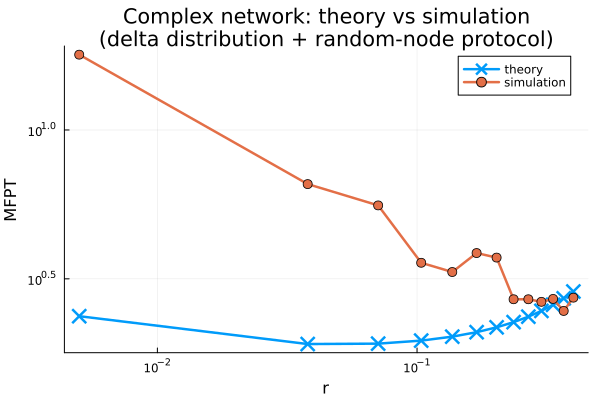

In [2]:
using Printf, Random, Graphs, Statistics, Plots

# QUICK THEORY VS SIMULATION CHECK
# Complex networks need both pieces specified explicitly:
# - reset_distribution: the magnetization target law
# - reset_protocol: the node-placement rule used by the simulator
# Here we only use the delta distribution + random-node protocol setup.

println("\n" * repeat("=", 90))
println("QUICK THEORY vs SIMULATION CHECK (complex network, delta dist + random-node protocol)")
println(repeat("=", 90))

N_check = 150
mu_check = 4.0
m0_check = 0.99
r_check_values = collect(range(0.005, 0.40, length = 13))
nsamples_check = 150

Random.seed!(2026)
g_full_check = erdos_renyi(N_check, mu_check / (N_check - 1))
components_check = connected_components(g_full_check)
if length(components_check) > 1
    largest_idx_check = argmax(length.(components_check))
    g_check, _ = induced_subgraph(g_full_check, components_check[largest_idx_check])
else
    g_check = g_full_check
end

actual_mu_check = 2 * ne(g_check) / nv(g_check)
println(@sprintf("Graph: N=%d, mean degree=%.2f, edges=%d", nv(g_check), actual_mu_check, ne(g_check)))
println()
println(@sprintf("%-8s %-14s %-14s %-14s", "r", "theory", "simulation", "rel_err"))
println(repeat('-', 70))

function mean_fpt_quick(graph, m0::Real, r::Real, reset_obj; nsamples::Int = 50)
    samples = VR.first_passage_time_discrete_complex(
        graph,
        VR.ComplexParams(r, m0);
        nsamples = nsamples,
        wait_for_consensus = true,
        reset = reset_obj,
    )
    valid = filter(x -> isfinite(x) && x > 0, samples)
    return isempty(valid) ? NaN : mean(valid)
end

reset_distribution = VR.delta_reset(m0_check)
reset_protocol = VR.random_node_reset(m0_check)

println(@sprintf("distribution = %s", nameof(typeof(reset_distribution))))
println(@sprintf("protocol     = %s", nameof(typeof(reset_protocol))))
println()

results = NamedTuple[]
for r in r_check_values
    t_theory = VR.complex_mfpt(g_check, m0_check; r = r)
    t_sim = mean_fpt_quick(g_check, m0_check, r, reset_protocol; nsamples = nsamples_check)
    rel_err = isfinite(t_theory) && t_theory > 0 ? abs(t_sim - t_theory) / t_theory : NaN
    push!(results, (r = r, theory = t_theory, simulation = t_sim, rel_err = rel_err))
    println(@sprintf("%-8.3f %-14.6e %-14.6e %-14.6e", r, t_theory, t_sim, rel_err))
end

r_plot = [x.r for x in results]
t_theory_plot = [x.theory for x in results]
t_sim_plot = [x.simulation for x in results]

p_compare = plot(
    r_plot,
    t_theory_plot,
    xlabel = "r",
    ylabel = "MFPT",
    title = "Complex network: theory vs simulation\n(delta distribution + random-node protocol)",
    xscale = :log10,
    yscale = :log10,
    linewidth = 2.5,
    marker = :x,
    markersize = 7,
    label = "theory",
)
plot!(p_compare, r_plot, t_sim_plot, linewidth = 2.5, marker = :circle, markersize = 5, label = "simulation")

display(p_compare)
p_compare

println(repeat("=", 90))

In [ ]:
using Random, Statistics, Printf, Plots

# SIMULATED BIFURCATION DIAGRAM FOR THE CURRENT COMPLEX-NETWORK PARAMETERS
# For each m0, sweep r, estimate MFPT from Monte Carlo trajectories, and pick the minimizer.

# Keep the graph fixed so the diagram matches the quick comparison parameters.
N_bif = nv(g_check)
mu_bif = actual_mu_check
m0_bif_values = collect(0.50:0.02:0.98)
r_bif_values = collect(range(0.0, 0.40, length = 17))
nsamples_bif = 250

println("\n" * repeat("=", 90))
println("SIMULATED COMPLEX-NETWORK BIFURCATION DIAGRAM")
println(repeat("=", 90))
println(@sprintf("Graph: N=%d, mean degree=%.2f, edges=%d", N_bif, mu_bif, ne(g_check)))
println(@sprintf("%-8s %-14s %-14s", "m0", "r*", "MFPT_sim(r*)"))
println(repeat('-', 50))

function mean_fpt_complex_scan(graph, m0::Real, r::Real; nsamples::Int = 250)
    samples = VR.first_passage_time_discrete_complex(
        graph,
        VR.ComplexParams(r, m0);
        nsamples = nsamples,
        wait_for_consensus = true,
        reset = VR.random_node_reset(m0),
    )
    valid = filter(x -> isfinite(x) && x > 0, samples)
    return isempty(valid) ? NaN : mean(valid)
end

r_star_bif = Float64[]
mfpt_star_bif = Float64[]

for m0 in m0_bif_values
    mfpt_curve = Float64[]
    for r in r_bif_values
        push!(mfpt_curve, mean_fpt_complex_scan(g_check, m0, r; nsamples = nsamples_bif))
    end

    valid_idx = findall(i -> isfinite(mfpt_curve[i]) && mfpt_curve[i] > 0, eachindex(mfpt_curve))
    if isempty(valid_idx)
        push!(r_star_bif, NaN)
        push!(mfpt_star_bif, NaN)
        continue
    end

    best_idx = valid_idx[argmin(mfpt_curve[valid_idx])]
    r_star = r_bif_values[best_idx]
    t_star = mfpt_curve[best_idx]

    push!(r_star_bif, r_star)
    push!(mfpt_star_bif, t_star)
    println(@sprintf("%-8.3f %-14.6e %-14.6e", m0, r_star, t_star))
end

valid_mask_bif = isfinite.(r_star_bif) .& (r_star_bif .> 0)
m0_plot_bif = m0_bif_values[valid_mask_bif]
r_plot_bif = r_star_bif[valid_mask_bif]

p_bif = plot(
    m0_plot_bif,
    r_plot_bif,
    xlabel = "m0 (initial magnetization)",
    ylabel = "r* (MFPT minimum)",
    title = "Simulated complex-network bifurcation diagram\n(N=$(N_bif), μ≈$(round(mu_bif, digits=2)), nsamples=$(nsamples_bif))",
    legend = false,
    linewidth = 2.5,
    marker = :circle,
    markersize = 4,
    yscale = :log10,
    xlims = (0.5, 1.0),
)

display(p_bif)
p_bif

println(repeat("=", 90))


SIMULATED COMPLEX-NETWORK BIFURCATION DIAGRAM
Graph: N=150, mean degree=4.29, edges=322
